# Task 4 — Variational Autoencoder



## Setup

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader

from torchvision import datasets, transforms


SEED = 42
BATCH_SIZE = 128
LATENT_DIM = 2
EPOCHS = 15
LR = 1e-3


torch.manual_seed(SEED)
np.random.seed(SEED)


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


RESULTS_DIR = Path("task4/results")
RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


print("Device:", device)

Device: cuda


## 4.1 Building a Basic VAE



### MNIST Dataset

In [3]:
transform = transforms.ToTensor()


train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)


print("Train images:", len(train_dataset))
print("Test images:", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 58.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.60MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 13.0MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.8MB/s]

Train images: 60000
Test images: 10000


### VAE Architecture

In [4]:
class VAE(nn.Module):
    def __init__(
        self,
        input_dim=784,
        hidden_dim=400,
        latent_dim=2,
    ):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
        )

        self.fc_mu = nn.Linear(
            hidden_dim,
            latent_dim,
        )

        self.fc_logvar = nn.Linear(
            hidden_dim,
            latent_dim,
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid(),
        )


    def encode(self, x):
        x = x.view(
            x.size(0),
            -1,
        )

        hidden = self.encoder(x)

        mu = self.fc_mu(hidden)
        logvar = self.fc_logvar(hidden)

        return mu, logvar


    def reparameterize(
        self,
        mu,
        logvar,
    ):
        std = torch.exp(
            0.5 * logvar
        )

        eps = torch.randn_like(std)

        return mu + std * eps


    def decode(self, z):
        reconstruction = self.decoder(z)

        return reconstruction.view(
            -1,
            1,
            28,
            28,
        )


    def forward(self, x):
        mu, logvar = self.encode(x)

        z = self.reparameterize(
            mu,
            logvar,
        )

        reconstruction = self.decode(z)

        return (
            reconstruction,
            mu,
            logvar,
        )

In [5]:
vae = VAE(
    latent_dim=LATENT_DIM
).to(device)


print(vae)

VAE(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=400, bias=True)
    (1): ReLU()
  )
  (fc_mu): Linear(in_features=400, out_features=2, bias=True)
  (fc_logvar): Linear(in_features=400, out_features=2, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=400, bias=True)
    (1): ReLU()
    (2): Linear(in_features=400, out_features=784, bias=True)
    (3): Sigmoid()
  )
)


### VAE Loss

In [6]:
def vae_loss(
    reconstruction,
    x,
    mu,
    logvar,
):
    reconstruction_loss = F.binary_cross_entropy(
        reconstruction,
        x,
        reduction="sum",
    )

    kl_divergence = -0.5 * torch.sum(
        1
        + logvar
        - mu.pow(2)
        - logvar.exp()
    )

    total_loss = (
        reconstruction_loss
        + kl_divergence
    )

    return (
        total_loss,
        reconstruction_loss,
        kl_divergence,
    )

### Training

In [7]:
optimizer = torch.optim.Adam(
    vae.parameters(),
    lr=LR,
)


history = {
    "epoch": [],
    "total_loss": [],
    "reconstruction_loss": [],
    "kl_divergence": [],
}


for epoch in range(1, EPOCHS + 1):
    vae.train()

    total_loss_sum = 0
    reconstruction_loss_sum = 0
    kl_divergence_sum = 0


    for images, _ in train_loader:
        images = images.to(device)

        optimizer.zero_grad()


        reconstruction, mu, logvar = vae(
            images
        )

        (
            loss,
            reconstruction_loss,
            kl_divergence,
        ) = vae_loss(
            reconstruction,
            images,
            mu,
            logvar,
        )


        loss.backward()
        optimizer.step()


        total_loss_sum += loss.item()
        reconstruction_loss_sum += (
            reconstruction_loss.item()
        )
        kl_divergence_sum += (
            kl_divergence.item()
        )


    num_samples = len(train_dataset)

    avg_total_loss = (
        total_loss_sum / num_samples
    )

    avg_reconstruction_loss = (
        reconstruction_loss_sum / num_samples
    )

    avg_kl_divergence = (
        kl_divergence_sum / num_samples
    )


    history["epoch"].append(epoch)

    history["total_loss"].append(
        avg_total_loss
    )

    history["reconstruction_loss"].append(
        avg_reconstruction_loss
    )

    history["kl_divergence"].append(
        avg_kl_divergence
    )


    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Loss: {avg_total_loss:.4f} | "
        f"Recon: {avg_reconstruction_loss:.4f} | "
        f"KL: {avg_kl_divergence:.4f}"
    )

Epoch 01/15 | Loss: 191.3612 | Recon: 185.5218 | KL: 5.8394
Epoch 02/15 | Loss: 168.4394 | Recon: 163.0154 | KL: 5.4240
Epoch 03/15 | Loss: 163.7505 | Recon: 158.2056 | KL: 5.5449
Epoch 04/15 | Loss: 161.1259 | Recon: 155.5208 | KL: 5.6052
Epoch 05/15 | Loss: 159.3324 | Recon: 153.6522 | KL: 5.6802
Epoch 06/15 | Loss: 157.9617 | Recon: 152.2279 | KL: 5.7338
Epoch 07/15 | Loss: 156.8674 | Recon: 151.0575 | KL: 5.8099
Epoch 08/15 | Loss: 156.0057 | Recon: 150.1631 | KL: 5.8425
Epoch 09/15 | Loss: 155.1941 | Recon: 149.3107 | KL: 5.8835
Epoch 10/15 | Loss: 154.4942 | Recon: 148.5621 | KL: 5.9321
Epoch 11/15 | Loss: 153.8278 | Recon: 147.8598 | KL: 5.9680
Epoch 12/15 | Loss: 153.3394 | Recon: 147.3233 | KL: 6.0161
Epoch 13/15 | Loss: 152.7767 | Recon: 146.7375 | KL: 6.0393
Epoch 14/15 | Loss: 152.3156 | Recon: 146.2591 | KL: 6.0565
Epoch 15/15 | Loss: 151.8771 | Recon: 145.8031 | KL: 6.0740


### Training History

In [8]:
history_df = pd.DataFrame(history)

history_path = (
    RESULTS_DIR /
    "vae_training_history.csv"
)

history_df.to_csv(
    history_path,
    index=False,
)


print(history_df)
print("\nSaved to:", history_path)

    epoch  total_loss  reconstruction_loss  kl_divergence
0       1  191.361238           185.521809       5.839429
1       2  168.439425           163.015385       5.424040
2       3  163.750483           158.205613       5.544870
3       4  161.125933           155.520767       5.605165
4       5  159.332403           153.652171       5.680232
5       6  157.961665           152.227887       5.733779
6       7  156.867386           151.057504       5.809883
7       8  156.005675           150.163132       5.842543
8       9  155.194143           149.310689       5.883454
9      10  154.494188           148.562065       5.932123
10     11  153.827833           147.859795       5.968038
11     12  153.339366           147.323264       6.016103
12     13  152.776739           146.737464       6.039275
13     14  152.315593           146.259078       6.056514
14     15  151.877119           145.803086       6.074034

Saved to: task4/results/vae_training_history.csv


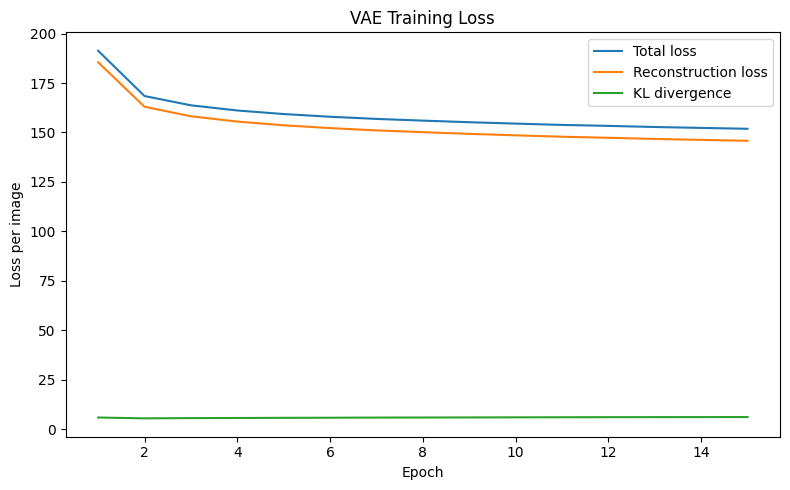

Saved to: task4/results/vae_training_loss.png


In [9]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["total_loss"],
    label="Total loss",
)

plt.plot(
    history_df["epoch"],
    history_df["reconstruction_loss"],
    label="Reconstruction loss",
)

plt.plot(
    history_df["epoch"],
    history_df["kl_divergence"],
    label="KL divergence",
)

plt.xlabel("Epoch")
plt.ylabel("Loss per image")
plt.title("VAE Training Loss")
plt.legend()
plt.tight_layout()


loss_plot_path = (
    RESULTS_DIR /
    "vae_training_loss.png"
)

plt.savefig(
    loss_plot_path,
    bbox_inches="tight",
)

plt.show()

print("Saved to:", loss_plot_path)

## 4.2 Analysis



### Latent Space Visualization

In [10]:
vae.eval()

latent_means = []
latent_labels = []


with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        mu, logvar = vae.encode(images)

        latent_means.append(
            mu.cpu().numpy()
        )

        latent_labels.append(
            labels.numpy()
        )


latent_means = np.concatenate(
    latent_means,
    axis=0,
)

latent_labels = np.concatenate(
    latent_labels,
    axis=0,
)


print(
    "Latent means:",
    latent_means.shape,
)

print(
    "Labels:",
    latent_labels.shape,
)

Latent means: (10000, 2)
Labels: (10000,)


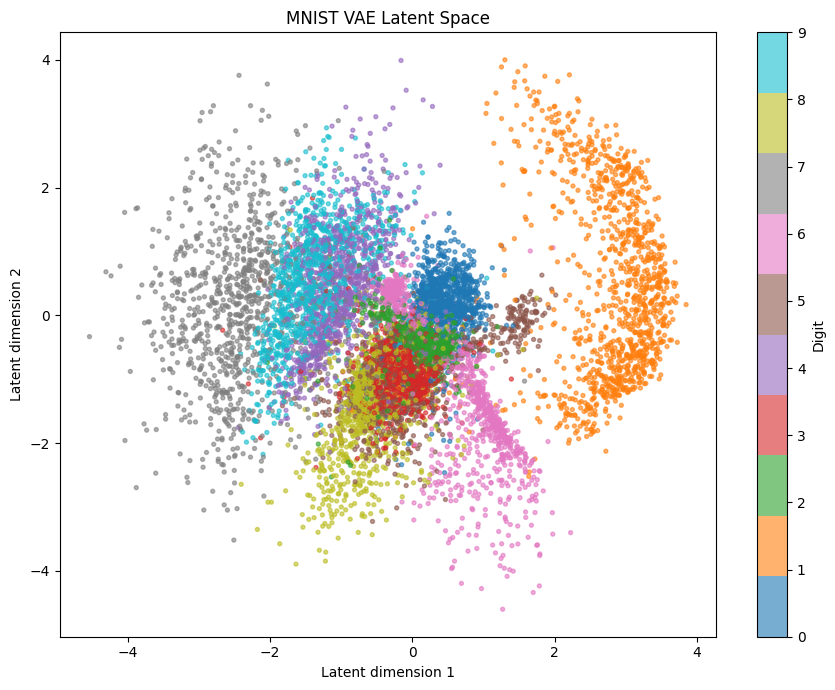

Saved to: task4/results/vae_latent_space.png


In [11]:
plt.figure(figsize=(9, 7))

scatter = plt.scatter(
    latent_means[:, 0],
    latent_means[:, 1],
    c=latent_labels,
    cmap="tab10",
    s=8,
    alpha=0.6,
)

cbar = plt.colorbar(
    scatter,
    ticks=range(10),
)

cbar.set_label("Digit")

plt.xlabel("Latent dimension 1")
plt.ylabel("Latent dimension 2")
plt.title("MNIST VAE Latent Space")
plt.tight_layout()


latent_path = (
    RESULTS_DIR /
    "vae_latent_space.png"
)

plt.savefig(
    latent_path,
    bbox_inches="tight",
)

plt.show()

print("Saved to:", latent_path)

### Original and Reconstructed Images

In [12]:
vae.eval()

images, labels = next(
    iter(test_loader)
)

images = images[:10].to(device)


with torch.no_grad():
    reconstruction, _, _ = vae(
        images
    )


images = images.cpu()
reconstruction = reconstruction.cpu()

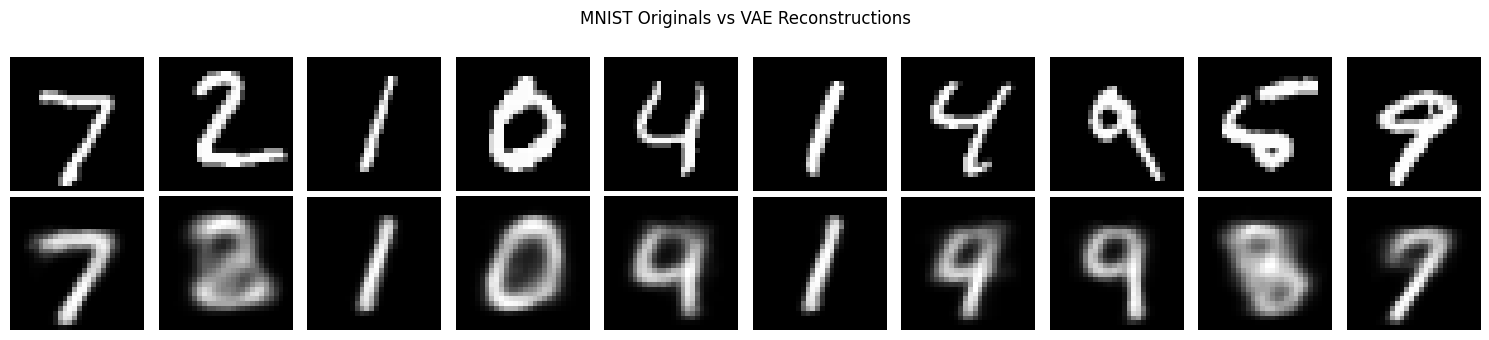

Saved to: task4/results/vae_reconstructions.png


In [13]:
fig, axes = plt.subplots(
    2,
    10,
    figsize=(15, 3.5),
)


for i in range(10):
    axes[0, i].imshow(
        images[i, 0],
        cmap="gray",
    )

    axes[0, i].axis("off")


    axes[1, i].imshow(
        reconstruction[i, 0],
        cmap="gray",
    )

    axes[1, i].axis("off")


axes[0, 0].set_ylabel(
    "Original",
    fontsize=12,
)

axes[1, 0].set_ylabel(
    "Reconstructed",
    fontsize=12,
)


plt.suptitle(
    "MNIST Originals vs VAE Reconstructions"
)

plt.tight_layout()


reconstruction_path = (
    RESULTS_DIR /
    "vae_reconstructions.png"
)

plt.savefig(
    reconstruction_path,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved to:",
    reconstruction_path,
)

### Samples from the Prior

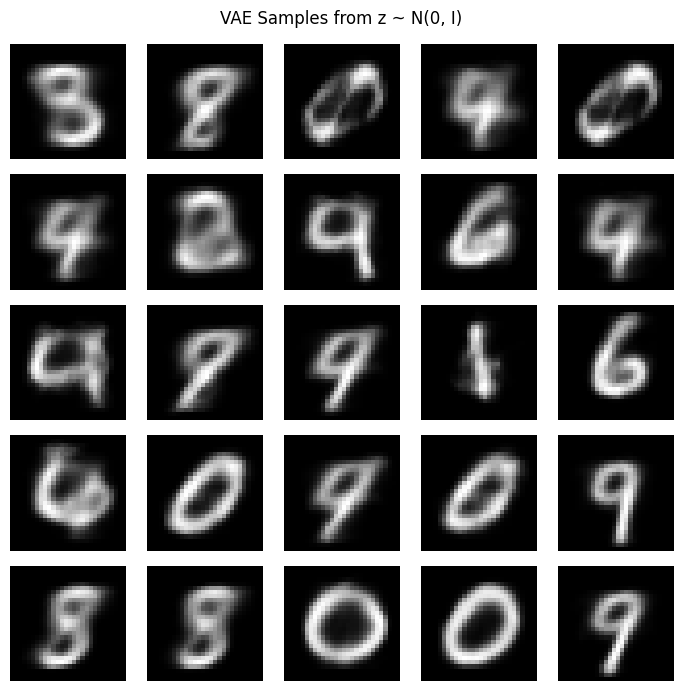

Saved to: task4/results/vae_generated_samples.png


In [14]:
NUM_SAMPLES = 25


vae.eval()

with torch.no_grad():
    z = torch.randn(
        NUM_SAMPLES,
        LATENT_DIM,
        device=device,
    )

    generated = vae.decode(
        z
    ).cpu()


fig, axes = plt.subplots(
    5,
    5,
    figsize=(7, 7),
)


for i, ax in enumerate(
    axes.flat
):
    ax.imshow(
        generated[i, 0],
        cmap="gray",
    )

    ax.axis("off")


plt.suptitle(
    "VAE Samples from z ~ N(0, I)"
)

plt.tight_layout()


generation_path = (
    RESULTS_DIR /
    "vae_generated_samples.png"
)

plt.savefig(
    generation_path,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved to:",
    generation_path,
)

## 4.3 Comparison with Doersch's VAE



### Effect of Latent Dimensionality

In [15]:
LATENT_DIM_COMPARE = 20


vae_20d = VAE(
    latent_dim=LATENT_DIM_COMPARE
).to(device)


optimizer_20d = torch.optim.Adam(
    vae_20d.parameters(),
    lr=LR,
)


history_20d = {
    "epoch": [],
    "total_loss": [],
    "reconstruction_loss": [],
    "kl_divergence": [],
}


print(vae_20d)

VAE(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=400, bias=True)
    (1): ReLU()
  )
  (fc_mu): Linear(in_features=400, out_features=20, bias=True)
  (fc_logvar): Linear(in_features=400, out_features=20, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=20, out_features=400, bias=True)
    (1): ReLU()
    (2): Linear(in_features=400, out_features=784, bias=True)
    (3): Sigmoid()
  )
)


### Training the 20-Dimensional VAE

In [16]:
for epoch in range(1, EPOCHS + 1):
    vae_20d.train()

    total_loss_sum = 0
    reconstruction_loss_sum = 0
    kl_divergence_sum = 0


    for images, _ in train_loader:
        images = images.to(device)

        optimizer_20d.zero_grad()


        reconstruction, mu, logvar = vae_20d(
            images
        )

        (
            loss,
            reconstruction_loss,
            kl_divergence,
        ) = vae_loss(
            reconstruction,
            images,
            mu,
            logvar,
        )


        loss.backward()
        optimizer_20d.step()


        total_loss_sum += loss.item()
        reconstruction_loss_sum += (
            reconstruction_loss.item()
        )
        kl_divergence_sum += (
            kl_divergence.item()
        )


    num_samples = len(train_dataset)

    avg_total_loss = (
        total_loss_sum / num_samples
    )

    avg_reconstruction_loss = (
        reconstruction_loss_sum / num_samples
    )

    avg_kl_divergence = (
        kl_divergence_sum / num_samples
    )


    history_20d["epoch"].append(epoch)

    history_20d["total_loss"].append(
        avg_total_loss
    )

    history_20d["reconstruction_loss"].append(
        avg_reconstruction_loss
    )

    history_20d["kl_divergence"].append(
        avg_kl_divergence
    )


    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Loss: {avg_total_loss:.4f} | "
        f"Recon: {avg_reconstruction_loss:.4f} | "
        f"KL: {avg_kl_divergence:.4f}"
    )

Epoch 01/15 | Loss: 164.0210 | Recon: 148.4643 | KL: 15.5568
Epoch 02/15 | Loss: 121.6361 | Recon: 99.2699 | KL: 22.3662
Epoch 03/15 | Loss: 114.5712 | Recon: 90.6557 | KL: 23.9156
Epoch 04/15 | Loss: 111.5340 | Recon: 87.0720 | KL: 24.4620
Epoch 05/15 | Loss: 109.7711 | Recon: 85.1202 | KL: 24.6509
Epoch 06/15 | Loss: 108.5689 | Recon: 83.7588 | KL: 24.8102
Epoch 07/15 | Loss: 107.7240 | Recon: 82.7880 | KL: 24.9360
Epoch 08/15 | Loss: 107.0667 | Recon: 82.0665 | KL: 25.0002
Epoch 09/15 | Loss: 106.4534 | Recon: 81.4450 | KL: 25.0084
Epoch 10/15 | Loss: 106.1095 | Recon: 80.9897 | KL: 25.1199
Epoch 11/15 | Loss: 105.6512 | Recon: 80.5413 | KL: 25.1098
Epoch 12/15 | Loss: 105.3676 | Recon: 80.1874 | KL: 25.1802
Epoch 13/15 | Loss: 105.0632 | Recon: 79.8960 | KL: 25.1672
Epoch 14/15 | Loss: 104.8043 | Recon: 79.5925 | KL: 25.2117
Epoch 15/15 | Loss: 104.6013 | Recon: 79.3926 | KL: 25.2087


### 2D vs 20D Training Results

In [17]:
history_20d_df = pd.DataFrame(
    history_20d
)


comparison_results = pd.DataFrame({
    "model": [
        "2D VAE",
        "20D VAE",
    ],
    "final_total_loss": [
        history_df["total_loss"].iloc[-1],
        history_20d_df["total_loss"].iloc[-1],
    ],
    "final_reconstruction_loss": [
        history_df[
            "reconstruction_loss"
        ].iloc[-1],

        history_20d_df[
            "reconstruction_loss"
        ].iloc[-1],
    ],
    "final_kl_divergence": [
        history_df[
            "kl_divergence"
        ].iloc[-1],

        history_20d_df[
            "kl_divergence"
        ].iloc[-1],
    ],
})


print(comparison_results)


comparison_path = (
    RESULTS_DIR /
    "vae_latent_dim_comparison.csv"
)

comparison_results.to_csv(
    comparison_path,
    index=False,
)

print(
    "\nSaved to:",
    comparison_path,
)

     model  final_total_loss  final_reconstruction_loss  final_kl_divergence
0   2D VAE        151.877119                 145.803086             6.074034
1  20D VAE        104.601299                  79.392586            25.208712

Saved to: task4/results/vae_latent_dim_comparison.csv


In [18]:
vae.eval()
vae_20d.eval()


comparison_images, _ = next(
    iter(test_loader)
)

comparison_images = (
    comparison_images[:10].to(device)
)


with torch.no_grad():
    reconstruction_2d, _, _ = vae(
        comparison_images
    )

    reconstruction_20d, _, _ = vae_20d(
        comparison_images
    )


comparison_images = (
    comparison_images.cpu()
)

reconstruction_2d = (
    reconstruction_2d.cpu()
)

reconstruction_20d = (
    reconstruction_20d.cpu()
)

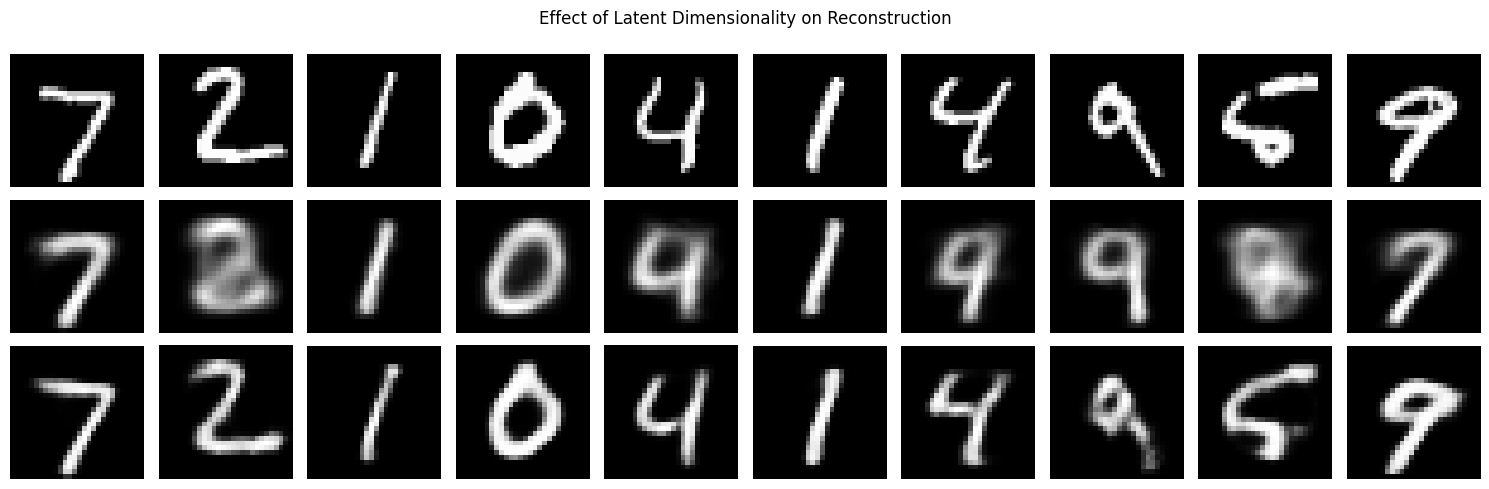

Saved to: task4/results/vae_2d_vs_20d_reconstructions.png


In [19]:
fig, axes = plt.subplots(
    3,
    10,
    figsize=(15, 5),
)


for i in range(10):
    axes[0, i].imshow(
        comparison_images[i, 0],
        cmap="gray",
    )

    axes[1, i].imshow(
        reconstruction_2d[i, 0],
        cmap="gray",
    )

    axes[2, i].imshow(
        reconstruction_20d[i, 0],
        cmap="gray",
    )


    for row in range(3):
        axes[row, i].axis("off")


axes[0, 0].set_ylabel(
    "Original",
    fontsize=11,
)

axes[1, 0].set_ylabel(
    "2D VAE",
    fontsize=11,
)

axes[2, 0].set_ylabel(
    "20D VAE",
    fontsize=11,
)


plt.suptitle(
    "Effect of Latent Dimensionality on Reconstruction"
)

plt.tight_layout()


comparison_recon_path = (
    RESULTS_DIR /
    "vae_2d_vs_20d_reconstructions.png"
)

plt.savefig(
    comparison_recon_path,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved to:",
    comparison_recon_path,
)

In [20]:
NUM_SAMPLES = 25


torch.manual_seed(SEED)
    

with torch.no_grad():
    z_2d = torch.randn(
        NUM_SAMPLES,
        2,
        device=device,
    )

    z_20d = torch.randn(
        NUM_SAMPLES,
        20,
        device=device,
    )


    generated_2d = vae.decode(
        z_2d
    ).cpu()

    generated_20d = vae_20d.decode(
        z_20d
    ).cpu()

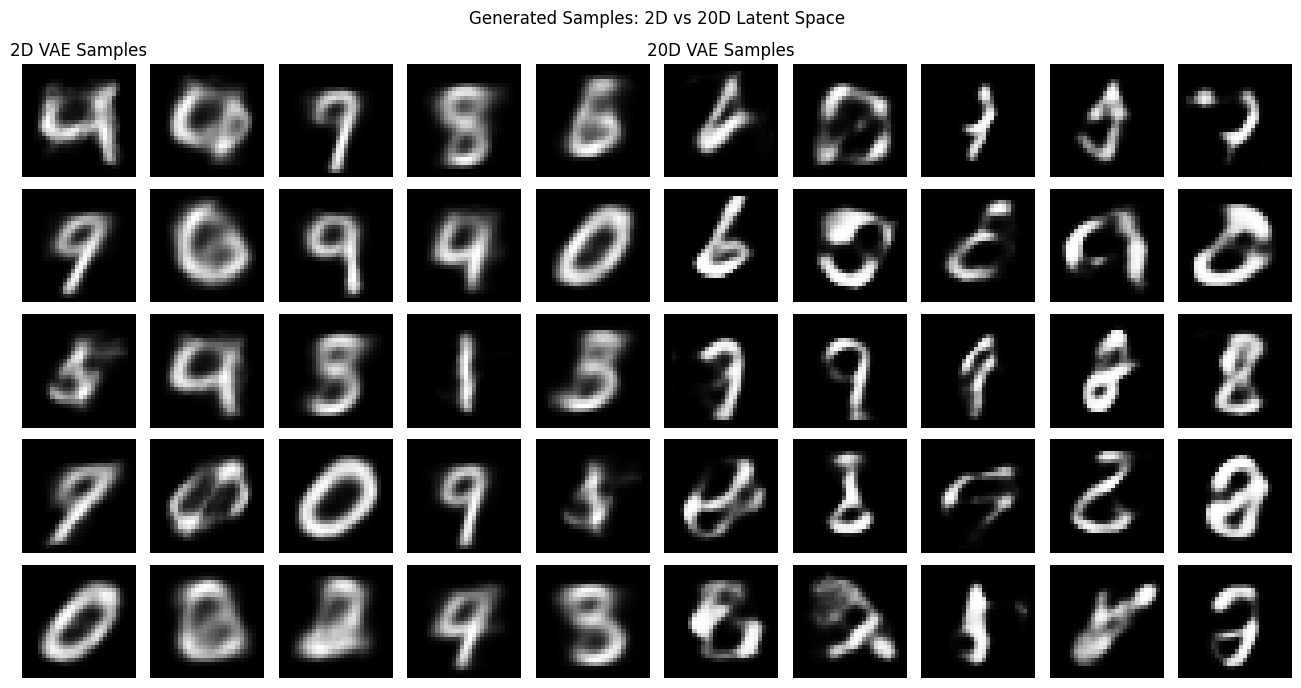

Saved to: task4/results/vae_2d_vs_20d_samples.png


In [21]:
fig, axes = plt.subplots(
    5,
    10,
    figsize=(13, 7),
)


for i in range(NUM_SAMPLES):
    row = i // 5
    col = i % 5


    axes[row, col].imshow(
        generated_2d[i, 0],
        cmap="gray",
    )

    axes[row, col].axis("off")


    axes[row, col + 5].imshow(
        generated_20d[i, 0],
        cmap="gray",
    )

    axes[row, col + 5].axis("off")


axes[0, 0].set_title(
    "2D VAE Samples"
)

axes[0, 5].set_title(
    "20D VAE Samples"
)


plt.suptitle(
    "Generated Samples: 2D vs 20D Latent Space"
)

plt.tight_layout()


sample_comparison_path = (
    RESULTS_DIR /
    "vae_2d_vs_20d_samples.png"
)

plt.savefig(
    sample_comparison_path,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved to:",
    sample_comparison_path,
)